# CH 6 : FIVE FACTORS DETERMINE THE MAGNITUDE OF THE DATA-MINING BIAS

> **Eurêka final :** le biais de minage de données n’est pas une force mystérieuse. Il augmente quand le hasard reçoit trop d’occasions de gagner, et il diminue quand la preuve statistique devient plus dense, plus longue et plus robuste.

Ce notebook transforme le concept EBTA en simulations concrètes.

Objectif : voir visuellement comment cinq facteurs modifient l’ampleur du **data-mining bias** dans un univers de règles de trading.


## 1. Le modèle mental EBTA

Dans une recherche de stratégies, la performance observée peut être vue comme :

$$
P_{obs} = P_{pred} + H
$$

où :

- $P_{obs}$ représente la **performance observée** en backtest.
- $P_{pred}$ représente le **pouvoir prédictif réel** de la règle.
- $H$ représente la part de **hasard**.

Le biais apparaît quand on teste beaucoup de règles puis qu’on sélectionne celle qui a le meilleur score historique.

> Même si toutes les règles ont un vrai mérite égal à zéro, l’une d’elles aura probablement un excellent résultat par pur hasard.


## 2. Les cinq facteurs

| Facteur | Effet sur le biais | Intuition trading |
|---|---:|---|
| Nombre de règles testées | Augmente le biais | Plus de tickets de loterie statistiques |
| Nombre d’observations | Réduit le biais | Plus de données = moins de bruit |
| Corrélation entre règles | Réduit le biais si forte | Des règles similaires comptent presque comme une seule famille |
| Outliers positifs | Augmentent le biais | Un trade chanceux peut faire gagner le concours |
| Variation du mérite réel | Réduit le biais si forte | Une vraie règle supérieure perce mieux le bruit |

> Le danger n’est pas seulement de tester beaucoup. Le danger est de tester beaucoup, sur peu de données, avec des règles indépendantes, exposées aux outliers, puis de croire que le gagnant est forcément talentueux.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


def simulate_rule_returns(
    n_rules=100,
    n_obs=250,
    true_means=None,
    sigma=1.0,
    corr=0.0,
    outlier_prob=0.0,
    outlier_scale=8.0,
    seed=42,
):
    """Simule les rendements de plusieurs règles candidates.

    Chaque colonne = une règle de trading.
    Chaque ligne = une observation, par exemple un trade ou une période.
    """
    local_rng = np.random.default_rng(seed)

    if true_means is None:
        true_means = np.zeros(n_rules)
    true_means = np.asarray(true_means)

    common_noise = local_rng.normal(0, sigma, size=(n_obs, 1))
    idiosyncratic_noise = local_rng.normal(0, sigma, size=(n_obs, n_rules))
    noise = np.sqrt(corr) * common_noise + np.sqrt(1 - corr) * idiosyncratic_noise

    returns = true_means + noise

    if outlier_prob > 0:
        jumps = local_rng.random(size=(n_obs, n_rules)) < outlier_prob
        positive_outliers = local_rng.exponential(outlier_scale, size=(n_obs, n_rules))
        returns = returns + jumps * positive_outliers

    return pd.DataFrame(returns, columns=[f"rule_{i+1}" for i in range(n_rules)])


def mine_best_rule(returns):
    """Sélectionne la règle avec la meilleure moyenne observée."""
    observed_means = returns.mean(axis=0)
    best_rule = observed_means.idxmax()
    return best_rule, observed_means.loc[best_rule], observed_means


## 3. Démonstration simple : un gagnant sans edge

On simule $100$ règles.

Hypothèse volontairement sévère : toutes ont un **vrai mérite nul**.

$$
P_{pred}=0
$$

Donc si une règle gagne, elle gagne uniquement grâce à $H$, le hasard.


Meilleure règle trouvée : rule_52
Performance moyenne observée : 0.111
Vrai mérite de toutes les règles : 0.000


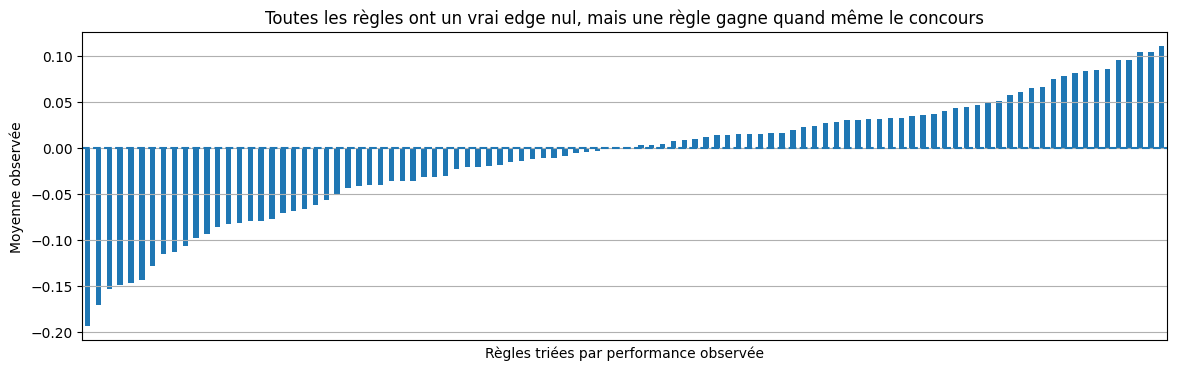

In [2]:
returns = simulate_rule_returns(n_rules=100, n_obs=250, seed=1)
best_rule, best_score, observed_means = mine_best_rule(returns)

print(f"Meilleure règle trouvée : {best_rule}")
print(f"Performance moyenne observée : {best_score:.3f}")
print("Vrai mérite de toutes les règles : 0.000")

observed_means.sort_values().plot(kind='bar', figsize=(14, 4))
plt.axhline(0, linestyle='--')
plt.title("Toutes les règles ont un vrai edge nul, mais une règle gagne quand même le concours")
plt.ylabel("Moyenne observée")
plt.xlabel("Règles triées par performance observée")
plt.xticks([])
plt.show()


> **Lecture EBTA :** le meilleur backtest n’est pas forcément le meilleur edge. Il peut simplement être la meilleure illusion produite par le bruit.


## 4. Facteur 1 — Nombre de règles testées

Plus on teste de règles, plus le maximum observé monte, même si toutes les règles sont inutiles.

C’est l’effet **concours de beauté statistique** : le gagnant paraît spécial parce qu’on a organisé beaucoup de comparaisons.


In [3]:
def experiment_number_of_rules(rule_counts, n_obs=250, n_trials=500, seed=123):
    local_rng = np.random.default_rng(seed)
    rows = []
    for n_rules in rule_counts:
        best_scores = []
        for trial in range(n_trials):
            r = simulate_rule_returns(
                n_rules=n_rules,
                n_obs=n_obs,
                seed=int(local_rng.integers(0, 1_000_000)),
            )
            _, best_score, _ = mine_best_rule(r)
            best_scores.append(best_score)
        rows.append({
            "n_rules": n_rules,
            "mean_best_score": np.mean(best_scores),
            "p95_best_score": np.percentile(best_scores, 95),
        })
    return pd.DataFrame(rows)

rule_counts = [1, 5, 10, 25, 50, 100, 250, 500, 1000]
df_rules = experiment_number_of_rules(rule_counts)
df_rules


,n_rules,mean_best_score,p95_best_score
0,1,-0.000326,0.106869
1,5,0.074101,0.144223
2,10,0.096934,0.163491
3,25,0.123721,0.176490
4,50,0.142677,0.197226
5,100,0.155483,0.204707
6,250,0.178548,0.223557
7,500,0.191163,0.229807
8,1000,0.206840,0.250318


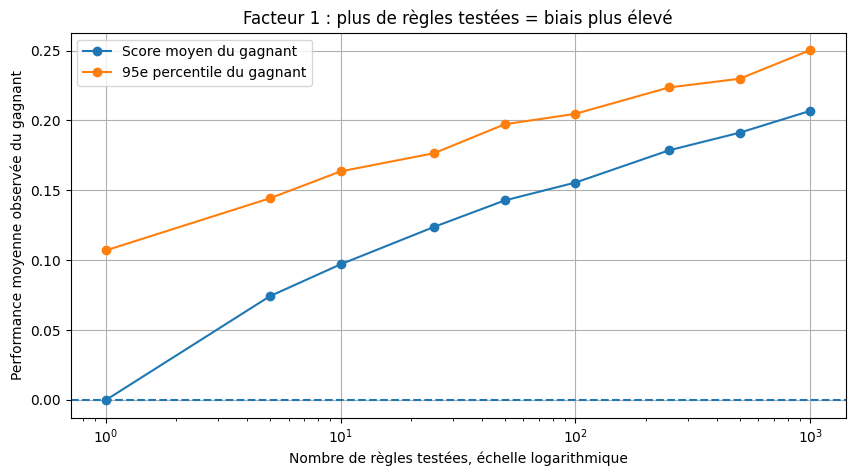

In [4]:
plt.plot(df_rules['n_rules'], df_rules['mean_best_score'], marker='o', label='Score moyen du gagnant')
plt.plot(df_rules['n_rules'], df_rules['p95_best_score'], marker='o', label='95e percentile du gagnant')
plt.xscale('log')
plt.axhline(0, linestyle='--')
plt.title("Facteur 1 : plus de règles testées = biais plus élevé")
plt.xlabel("Nombre de règles testées, échelle logarithmique")
plt.ylabel("Performance moyenne observée du gagnant")
plt.legend()
plt.show()


## 5. Facteur 2 — Nombre d’observations

La taille de l’échantillon est probablement le frein le plus puissant contre le mirage.

Quand $n$ augmente, la moyenne observée devient plus stable.

$$
\text{Erreur standard} \approx \frac{\sigma}{\sqrt{n}}
$$

Donc plus $n$ est grand, plus le hasard a du mal à créer un faux champion.


In [5]:
def experiment_number_of_observations(obs_counts, n_rules=100, n_trials=500, seed=456):
    local_rng = np.random.default_rng(seed)
    rows = []
    for n_obs in obs_counts:
        best_scores = []
        for trial in range(n_trials):
            r = simulate_rule_returns(
                n_rules=n_rules,
                n_obs=n_obs,
                seed=int(local_rng.integers(0, 1_000_000)),
            )
            _, best_score, _ = mine_best_rule(r)
            best_scores.append(best_score)
        rows.append({
            "n_obs": n_obs,
            "mean_best_score": np.mean(best_scores),
            "p95_best_score": np.percentile(best_scores, 95),
        })
    return pd.DataFrame(rows)

obs_counts = [25, 50, 100, 250, 500, 1000, 2500, 5000]
df_obs = experiment_number_of_observations(obs_counts)
df_obs


,n_obs,mean_best_score,p95_best_score
0,25,0.502401,0.674075
1,50,0.357389,0.475676
2,100,0.249714,0.325589
3,250,0.160580,0.209868
4,500,0.112337,0.148839
5,1000,0.079533,0.103714
6,2500,0.049928,0.065087
7,5000,0.035979,0.047135


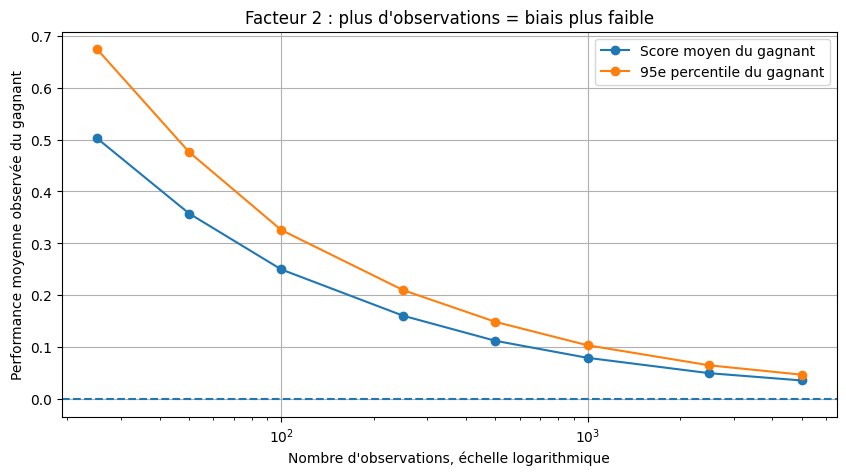

In [6]:
plt.plot(df_obs['n_obs'], df_obs['mean_best_score'], marker='o', label='Score moyen du gagnant')
plt.plot(df_obs['n_obs'], df_obs['p95_best_score'], marker='o', label='95e percentile du gagnant')
plt.xscale('log')
plt.axhline(0, linestyle='--')
plt.title("Facteur 2 : plus d'observations = biais plus faible")
plt.xlabel("Nombre d'observations, échelle logarithmique")
plt.ylabel("Performance moyenne observée du gagnant")
plt.legend()
plt.show()


## 6. Facteur 3 — Corrélation entre règles

Tester $100$ variantes très proches n’est pas équivalent à tester $100$ idées totalement différentes.

Si les règles sont très corrélées, elles réagissent presque au même bruit.

Si elles sont décorrélées, chacune donne une nouvelle opportunité au hasard.


In [7]:
def experiment_correlation(correlations, n_rules=100, n_obs=250, n_trials=500, seed=789):
    local_rng = np.random.default_rng(seed)
    rows = []
    for corr in correlations:
        best_scores = []
        for trial in range(n_trials):
            r = simulate_rule_returns(
                n_rules=n_rules,
                n_obs=n_obs,
                corr=corr,
                seed=int(local_rng.integers(0, 1_000_000)),
            )
            _, best_score, _ = mine_best_rule(r)
            best_scores.append(best_score)
        rows.append({
            "corr": corr,
            "mean_best_score": np.mean(best_scores),
            "p95_best_score": np.percentile(best_scores, 95),
        })
    return pd.DataFrame(rows)

correlations = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
df_corr = experiment_correlation(correlations)
df_corr


,corr,mean_best_score,p95_best_score
0,0.00,0.157197,0.205520
1,0.10,0.149977,0.210235
2,0.25,0.137896,0.195598
3,0.50,0.111057,0.189146
4,0.75,0.079263,0.175587
5,0.90,0.047587,0.146156
6,0.99,0.019266,0.119344


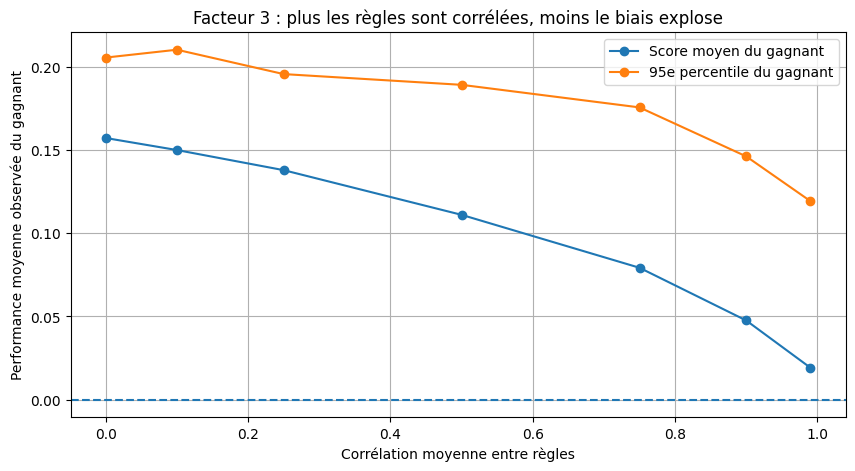

In [8]:
plt.plot(df_corr['corr'], df_corr['mean_best_score'], marker='o', label='Score moyen du gagnant')
plt.plot(df_corr['corr'], df_corr['p95_best_score'], marker='o', label='95e percentile du gagnant')
plt.axhline(0, linestyle='--')
plt.title("Facteur 3 : plus les règles sont corrélées, moins le biais explose")
plt.xlabel("Corrélation moyenne entre règles")
plt.ylabel("Performance moyenne observée du gagnant")
plt.legend()
plt.show()


## 7. Facteur 4 — Outliers positifs

Les marchés ne produisent pas toujours des rendements sages et gaussiens.

Un seul trade énorme peut transformer une règle moyenne en superstar de backtest.

> Une règle peut gagner non parce qu’elle sait prédire, mais parce qu’elle était exposée au bon moment, par accident.


In [9]:
settings = [
    {"label": "Sans outliers", "outlier_prob": 0.0, "outlier_scale": 0.0},
    {"label": "Outliers rares", "outlier_prob": 0.002, "outlier_scale": 8.0},
    {"label": "Outliers plus fréquents", "outlier_prob": 0.01, "outlier_scale": 8.0},
]

rows = []
for i, s in enumerate(settings):
    best_scores = []
    for trial in range(500):
        r = simulate_rule_returns(
            n_rules=100,
            n_obs=250,
            outlier_prob=s['outlier_prob'],
            outlier_scale=s['outlier_scale'],
            seed=10_000 + trial + i * 10_000,
        )
        _, best_score, _ = mine_best_rule(r)
        best_scores.append(best_score)
    rows.append({
        "scenario": s['label'],
        "mean_best_score": np.mean(best_scores),
        "p95_best_score": np.percentile(best_scores, 95),
    })

df_outliers = pd.DataFrame(rows)
df_outliers


,scenario,mean_best_score,p95_best_score
0,Sans outliers,0.158593,0.207372
1,Outliers rares,0.217601,0.309961
2,Outliers plus fréquents,0.383982,0.527681


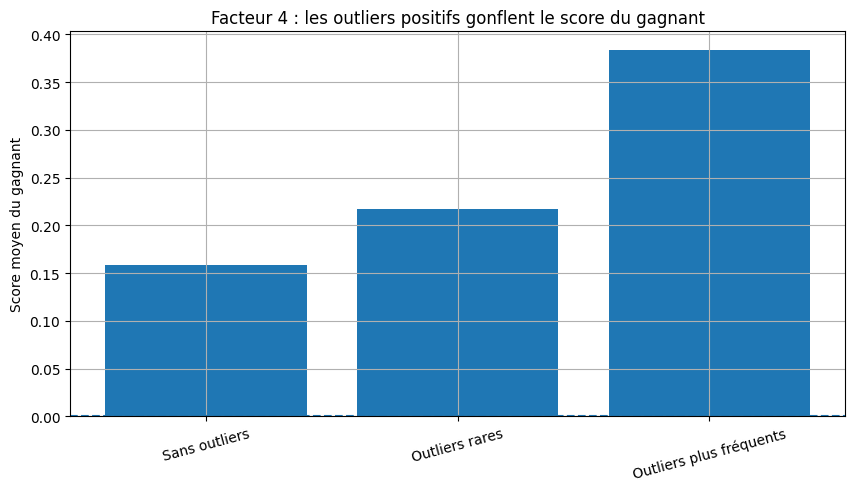

In [10]:
plt.bar(df_outliers['scenario'], df_outliers['mean_best_score'])
plt.axhline(0, linestyle='--')
plt.title("Facteur 4 : les outliers positifs gonflent le score du gagnant")
plt.ylabel("Score moyen du gagnant")
plt.xticks(rotation=15)
plt.show()


## 8. Facteur 5 — Variation du mérite réel

Si toutes les règles ont un mérite proche de zéro, le gagnant est presque entièrement choisi par le hasard.

Mais si certaines règles ont un vrai avantage beaucoup plus élevé, le signal réel peut dépasser le bruit.

La question EBTA devient alors :

> Le gagnant est-il simplement chanceux, ou son mérite réel est-il assez fort pour survivre à la sélection ?


In [11]:
def experiment_true_merit(merit_spreads, n_rules=100, n_obs=250, n_trials=500, seed=999):
    local_rng = np.random.default_rng(seed)
    rows = []
    for spread in merit_spreads:
        selected_true_merits = []
        selected_observed = []
        for trial in range(n_trials):
            true_means = local_rng.normal(0, spread, size=n_rules)
            r = simulate_rule_returns(
                n_rules=n_rules,
                n_obs=n_obs,
                true_means=true_means,
                seed=int(local_rng.integers(0, 1_000_000)),
            )
            best_rule, best_score, _ = mine_best_rule(r)
            idx = int(best_rule.split('_')[1]) - 1
            selected_true_merits.append(true_means[idx])
            selected_observed.append(best_score)
        rows.append({
            "merit_spread": spread,
            "avg_true_merit_of_winner": np.mean(selected_true_merits),
            "avg_observed_score_of_winner": np.mean(selected_observed),
            "avg_bias": np.mean(np.array(selected_observed) - np.array(selected_true_merits)),
        })
    return pd.DataFrame(rows)

merit_spreads = [0.0, 0.02, 0.05, 0.1, 0.2, 0.4]
df_merit = experiment_true_merit(merit_spreads)
df_merit


,merit_spread,avg_true_merit_of_winner,avg_observed_score_of_winner,avg_bias
0,0.00,0.000000,0.157525,0.157525
1,0.02,0.015181,0.168187,0.153006
2,0.05,0.080113,0.203379,0.123266
3,0.10,0.216563,0.297934,0.081371
4,0.20,0.472508,0.519933,0.047425
5,0.40,0.992361,1.017069,0.024709


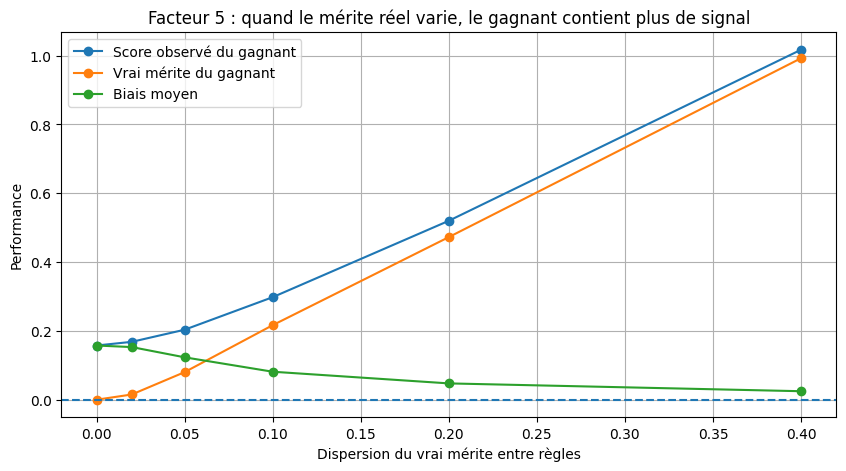

In [12]:
plt.plot(df_merit['merit_spread'], df_merit['avg_observed_score_of_winner'], marker='o', label='Score observé du gagnant')
plt.plot(df_merit['merit_spread'], df_merit['avg_true_merit_of_winner'], marker='o', label='Vrai mérite du gagnant')
plt.plot(df_merit['merit_spread'], df_merit['avg_bias'], marker='o', label='Biais moyen')
plt.axhline(0, linestyle='--')
plt.title("Facteur 5 : quand le mérite réel varie, le gagnant contient plus de signal")
plt.xlabel("Dispersion du vrai mérite entre règles")
plt.ylabel("Performance")
plt.legend()
plt.show()


## 9. Mini-backtest conceptuel : concours de règles aléatoires

On peut relier cela au trading avec une simulation simple :

- Chaque règle génère des trades.
- Aucun signal n’a d’edge réel.
- On sélectionne la meilleure courbe.

Le piège : la meilleure courbe semble tradable, mais elle est issue d’un concours de hasard.


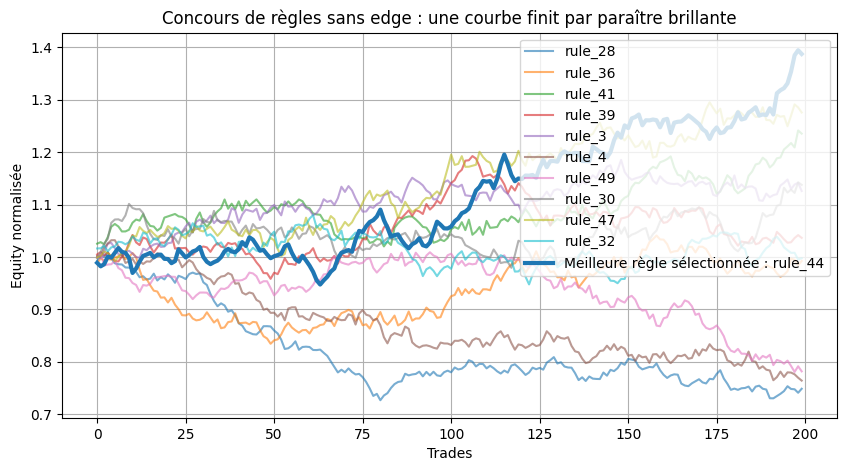

Règle gagnante : rule_44
Equity finale gagnante : 1.387
Vrai edge de toutes les règles : zéro


In [19]:
n_rules = 50
n_trades = 200
returns = simulate_rule_returns(n_rules=n_rules, n_obs=n_trades, sigma=1.0, seed=2026) / 100
cum_equity = (1 + returns).cumprod()

final_values = cum_equity.iloc[-1]
best_col = final_values.idxmax()

cum_equity.sample(n=10, axis=1, random_state=1).plot(alpha=0.6, legend=False)
cum_equity[best_col].plot(linewidth=3, label=f"Meilleure règle sélectionnée : {best_col}")
plt.title("Concours de règles sans edge : une courbe finit par paraître brillante")
plt.xlabel("Trades")
plt.ylabel("Equity normalisée")
plt.legend()
plt.show()

print(f"Règle gagnante : {best_col}")
print(f"Equity finale gagnante : {final_values[best_col]:.3f}")
print("Vrai edge de toutes les règles : zéro")


## 10. Checklist EBTA anti-mirage

| Question | Pourquoi elle compte |
|---|---|
| Combien de règles ai-je réellement testées ? | Mesure l’opportunité donnée au hasard |
| Combien d’observations ou trades ? | Mesure la densité de preuve |
| Les règles sont-elles corrélées ? | Estime le nombre effectif de tests indépendants |
| Un outlier explique-t-il la performance ? | Détecte les champions accidentels |
| Le gagnant reste-t-il bon hors-échantillon ? | Sépare le mérite du hasard |
| La performance survit-elle au bootstrap ou au walk-forward ? | Teste la robustesse du signal |

> **Règle pratique :** plus la recherche est large, plus la preuve exigée doit être forte.


## 11. Synthèse finale

Le biais de minage de données est amplifié par :

- beaucoup de règles testées ;
- peu d’observations ;
- des règles très différentes ;
- des outliers positifs ;
- peu ou pas de variation réelle du mérite entre règles.

Il est réduit par :

- plus de données ;
- des familles de règles cohérentes ;
- une gestion stricte des outliers ;
- une validation hors-échantillon ;
- une hypothèse claire avant le test.

> **Eurêka final :** un backtest gagnant ne prouve pas un edge. Il prouve d’abord qu’une règle a gagné un concours. EBTA commence quand on mesure si ce concours était honnête ou truqué par le hasard.


## 12. Annexe — Source originale collée

Le texte ci-dessous est conservé comme annexe de travail.


### **CH 6 : FIVE FACTORS DETERMINE THE MAGNITUDE OF THE DATA-MINING BIAS**

Voici l’analyse technique des cinq facteurs qui déterminent l’ampleur du biais de minage de données, tels que définis et illustrés par David Aronson dans le Chapitre 6.

---

#### **(AJOUT) Idées clés :**
*   **Les variables du mirage :** Le biais de minage n'est pas une valeur fixe ; son intensité dépend de la structure de la recherche et de la nature des données.
*   **La primauté de l'échantillon :** La taille de l'échantillon (nombre d'observations) est probablement le facteur le plus crucial pour réduire le biais.
*   **L'illusion du nombre :** Plus le nombre de règles testées augmente, plus le profit du "gagnant" s'éloigne de la réalité.
*   **L'effet de la diversité :** Tester des règles très différentes (décorrélées) augmente le biais par rapport à l'optimisation de paramètres d'une seule règle.
*   **Le danger des extrêmes :** La présence de "gros" trades gagnants accidentels (outliers) gonfle artificiellement le biais.

---

#### **Référence :**
*Five Factors Determine the Magnitude of the Data-Mining Bias*, Chapitre 6, pages 287 à 291.

---

#### **Citation Directe :**
« Observed performance is a combination of randomness and predictive power. The greater the relative contribution of randomness, the larger will be the magnitude the data-mining bias. » (Page 287).

---

#### **Vision Macro :**
L'enjeu est de comprendre la "météorologie" du hasard. David Aronson explique que le trader n'est pas impuissant face au biais de minage de données : s'il ne peut pas l'éliminer totalement, il peut en prédire l'intensité. En identifiant les réglages qui "boostent" la chance (comme tester trop de règles sur un historique trop court), le trader EBTA peut ajuster son niveau de scepticisme et éviter de prendre du « métal des fous » pour de l'or véritable.

---

#### **Vision Micro :**

Aronson définit cinq facteurs techniques agissant sur le biais :

1.  **Le nombre de règles testées ($N$) :** Le biais croît de manière quasi linéaire par rapport au logarithme du nombre de règles. Plus vous offrez de tentatives au hasard (comme multiplier les singes sur des claviers), plus la probabilité d'un résultat "miraculeux" augmente.
2.  **Le nombre d'observations :** Plus l'historique de données est long, plus la distribution d'échantillonnage se resserre autour de la moyenne réelle (Loi des Grands Nombres). Un échantillon large "dilue" la chance et réduit drastiquement le biais.
3.  **La corrélation entre les règles :** Si les règles testées se ressemblent toutes (ex: optimiser une moyenne mobile de 20 vs 21 jours), le biais est faible car vous testez virtuellement la "même" règle. Si les règles sont décorrélées (indépendantes), le biais est maximal car chaque test est une nouvelle chance offerte au hasard.
4.  **La présence d'outliers positifs :** Les marchés financiers ont des "queues épaisses" (heavy tails). Une règle peut gagner le "concours" de backtest simplement parce qu'elle était positionnée par pur accident lors d'un krach ou d'une hausse massive. Ces événements rares gonflent le biais car ils ne sont pas récurrents.
5.  **La variation du mérite réel :** Si toutes les règles testées sont médiocres (mérite proche de zéro), le gagnant sera désigné uniquement par la chance, créant un biais énorme. Si une règle est massivement supérieure aux autres, son talent "percera le brouillard" et le biais de sélection sera réduit.

---

#### **(AJOUT) Résumé Simplifié :**
Imaginez un concours de tir à l'arc dans le brouillard. Le biais (le mensonge du score) augmente si :
1. Il y a des milliers de tireurs (plus de chances qu'un nul touche le centre par accident).
2. Ils ne tirent qu'une seule flèche (pas assez de preuves pour juger).
3. Ils tirent tous dans des directions différentes (plus de zones couvertes au hasard).
4. Une rafale de vent pousse soudainement une flèche vers le centre (coup de bol outlier).
5. Aucun tireur n'est vraiment pro (le gagnant est forcément un chanceux).

---

#### **Actions Concrètes :**
*   **Prioriser la longueur des données :** Avant d'ajouter des règles à votre univers de test, assurez-vous d'avoir assez de données (N élevé) pour "noyer" le biais.
*   **Limiter les tests de règles décorrélées :** Soyez deux fois plus prudent lorsque vous mélangez des indicateurs de types très différents (ex: RSI + Volume + Astro) que lors d'une simple optimisation de paramètres.
*   **Utiliser des sorties à objectif fixe :** Pour réduire le facteur 4 (outliers), utilisez des "targets" de profit fixes, ce qui coupe les gains extrêmes accidentels et stabilise la statistique.
*   **Heed the Law of Large Numbers :** Ne croyez jamais un backtest basé sur moins de quelques centaines de trades ou de mois de données.

---

#### **(AJOUT) À retenir absolument :**
*   **Plus de tests = Plus de mensonge** (Biais $N$ élevé).
*   **Plus de données = Plus de vérité** (Biais $Obs$ faible).
*   La **corrélation** entre les règles est votre alliée contre le biais.
*   Le **bruit du marché (outliers)** est l'ennemi n°1 de l'estimation.
*   Le minage de données ne fonctionne **que si l'échantillon est large**.

J'ai terminé l'analyse des cinq facteurs déterminant l'ampleur du biais de minage selon le protocole EBTA.
